# Exploratory Data Analysis on Retail Sales Data

## OIBSIP – Data Analytics Internship

### Task 1: Exploratory Data Analysis (EDA) on Retail Sales Data

**Submitted by:** Vageesha Kriti

## 1. Introduction

Exploratory Data Analysis (EDA) is the process of analysing and understanding a dataset using statistical methods and visualisations.

In this project, Exploratory Data Analysis is performed on a Retail Sales Dataset containing customer transactions. The objective is to identify sales trends, understand customer demographics, analyse product performance, and discover meaningful relationships between different variables.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

## 2. Loading the Dataset

The retail sales dataset is loaded using the Pandas library for further analysis.

In [33]:
df = pd.read_csv(r'C:\Users\Vageesha Kriti\OneDrive\Desktop\OIBSIP_Data_Analytics\oibsip_retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Product,Quantity,Price per Unit,Total Amount
0,T00001,2023-03-20,C1416,Female,28,Clothing,Shoes,4,2572.13,10288.52
1,T00002,2023-10-12,C1004,Male,43,Sports,Football,3,1265.99,3797.97
2,T00003,2023-06-06,C1075,Female,56,Home & Kitchen,Mixer Grinder,3,3448.96,10346.88
3,T00004,2024-06-22,C1195,Female,37,Beauty,Shampoo,2,486.83,973.66
4,T00005,2023-03-25,C1262,Female,46,Electronics,Laptop,4,55860.40,223441.60


## 3. Dataset Overview and Initial Inspection

The dataset contains retail transaction records with information about customers, products, quantities, prices, and total sales amounts.

The following analysis checks the dataset structure, data types, missing values, duplicate records, and the first few rows of the dataset.

In [13]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (1200, 10)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    1200 non-null   str    
 1   Date              1200 non-null   str    
 2   Customer ID       1200 non-null   str    
 3   Gender            1200 non-null   str    
 4   Age               1200 non-null   int64  
 5   Product Category  1200 non-null   str    
 6   Product           1200 non-null   str    
 7   Quantity          1200 non-null   int64  
 8   Price per Unit    1200 non-null   float64
 9   Total Amount      1200 non-null   float64
dtypes: float64(2), int64(2), str(6)
memory usage: 145.1 KB

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Product             0
Quantity            0
Price per Unit      0
Total Amount     

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Product,Quantity,Price per Unit,Total Amount
0,T00001,2023-03-20,C1416,Female,28,Clothing,Shoes,4,2572.13,10288.52
1,T00002,2023-10-12,C1004,Male,43,Sports,Football,3,1265.99,3797.97
2,T00003,2023-06-06,C1075,Female,56,Home & Kitchen,Mixer Grinder,3,3448.96,10346.88
3,T00004,2024-06-22,C1195,Female,37,Beauty,Shampoo,2,486.83,973.66
4,T00005,2023-03-25,C1262,Female,46,Electronics,Laptop,4,55860.40,223441.60


## 4. Data Cleaning

The dataset is checked for missing values and duplicate records to ensure that the data is suitable for analysis.

Since the dataset does not contain missing values, it can be directly used for further Exploratory Data Analysis.

## 5. Descriptive Statistics

The following analysis calculates the mean, median, mode, and standard deviation of the numerical variables.

In [14]:
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

statistics = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Mode': df[numerical_cols].mode().iloc[0],
    'Standard Deviation': df[numerical_cols].std()
})

print(statistics)

                        Mean  Median     Mode  Standard Deviation
Age                41.275833    41.0    21.00           13.960199
Quantity            3.016667     3.0     4.00            1.426447
Price per Unit   8176.746700  2368.8  1229.97        15478.695038
Total Amount    24859.125583  6540.1   396.26        53904.480840


In [15]:
df[numerical_cols].describe()

,Age,Quantity,Price per Unit,Total Amount
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,41.275833,3.016667,8176.746700,24859.125583
std,13.960199,1.426447,15478.695038,53904.480840
min,18.000000,1.000000,385.940000,396.260000
25%,29.000000,2.000000,1210.025000,2869.625000
50%,41.000000,3.000000,2368.800000,6540.100000
75%,54.000000,4.000000,3761.030000,13509.827500
max,65.000000,5.000000,74567.530000,360850.950000


## 6. Sales Trend Analysis

Monthly and quarterly sales trends are analysed to understand how sales change over time.

In [16]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1200 non-null   str           
 1   Date              1200 non-null   datetime64[us]
 2   Customer ID       1200 non-null   str           
 3   Gender            1200 non-null   str           
 4   Age               1200 non-null   int64         
 5   Product Category  1200 non-null   str           
 6   Product           1200 non-null   str           
 7   Quantity          1200 non-null   int64         
 8   Price per Unit    1200 non-null   float64       
 9   Total Amount      1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 133.4 KB


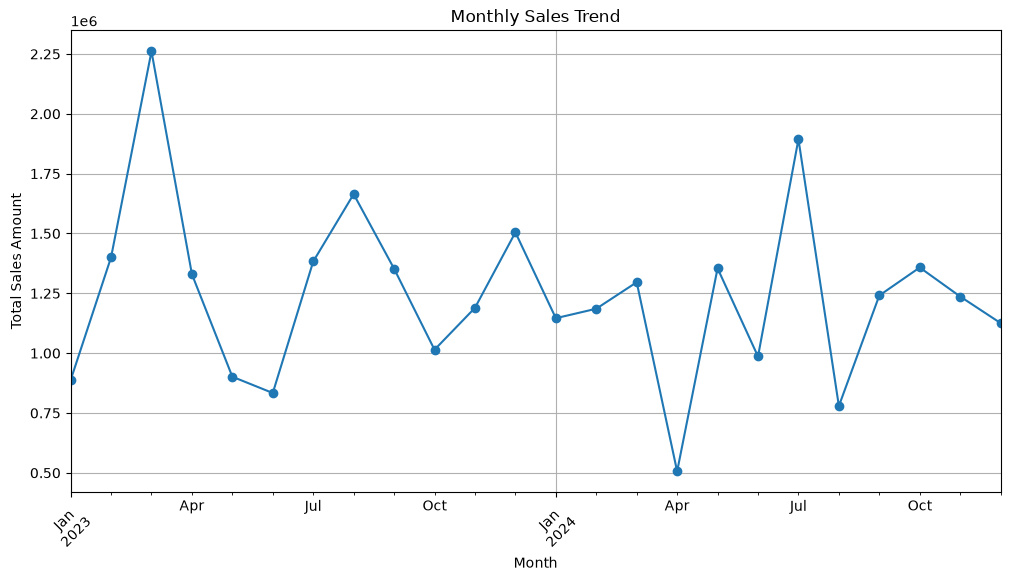

In [17]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

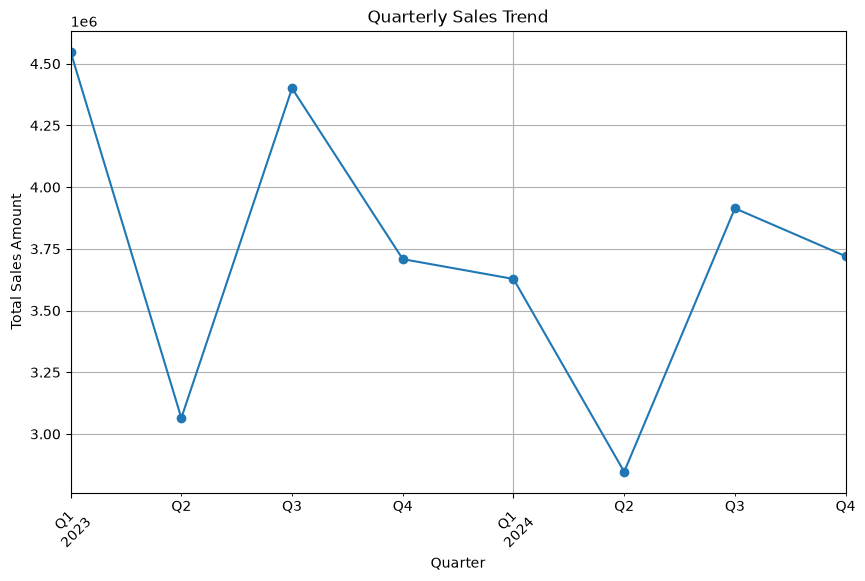

In [18]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(10, 6))
quarterly_sales.plot(marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 7. Customer Demographics Analysis

This section analyses customer age groups and gender distribution.

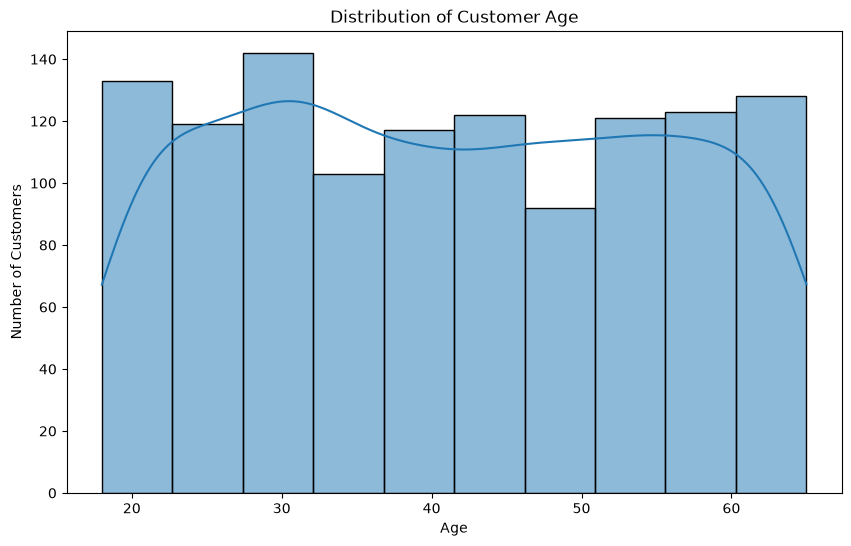

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

In [35]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['Below 20', '21-30', '31-40', '41-50', '51-60', 'Above 60']
)

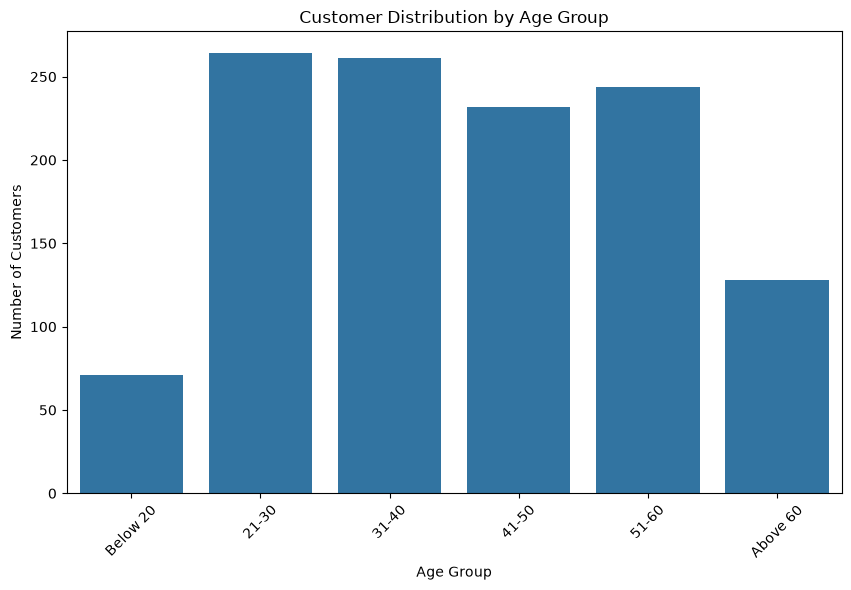

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Age Group')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

Gender
Female    628
Male      572
Name: count, dtype: int64


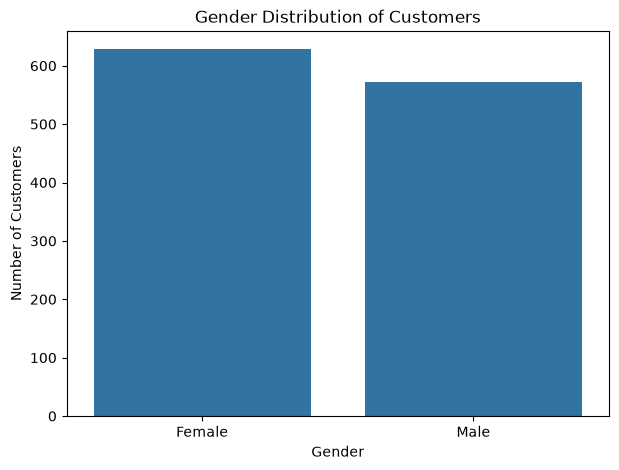

In [22]:
gender_counts = df['Gender'].value_counts()

print(gender_counts)

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Gender')

plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

## 8. Product and Category Analysis

This section identifies the best-selling products and the product categories generating the highest revenue.

Product
Headphones       212
Smartphone       210
Jacket           208
Laptop           196
Tablet           175
Lipstick         175
Water Bottle     170
Jeans            166
Skin Care Kit    165
Smartwatch       164
Name: Quantity, dtype: int64


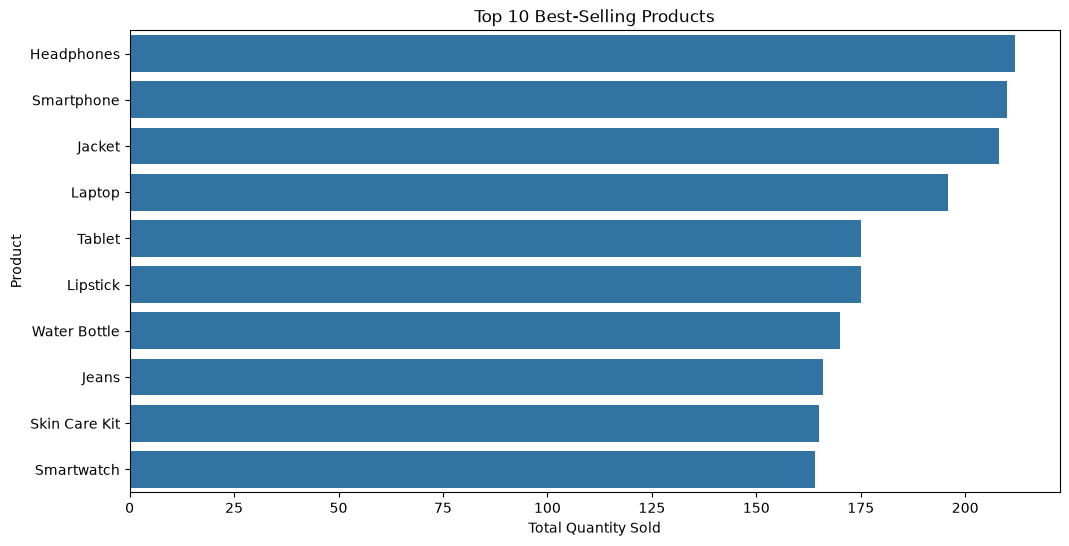

In [23]:
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).head(10)

print(top_products)

plt.figure(figsize=(12, 6))

sns.barplot(x=top_products.values, y=top_products.index)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')

plt.show()

Product Category
Electronics       24724703.26
Clothing           1931054.85
Sports             1309221.16
Home & Kitchen     1050289.77
Beauty              815681.66
Name: Total Amount, dtype: float64


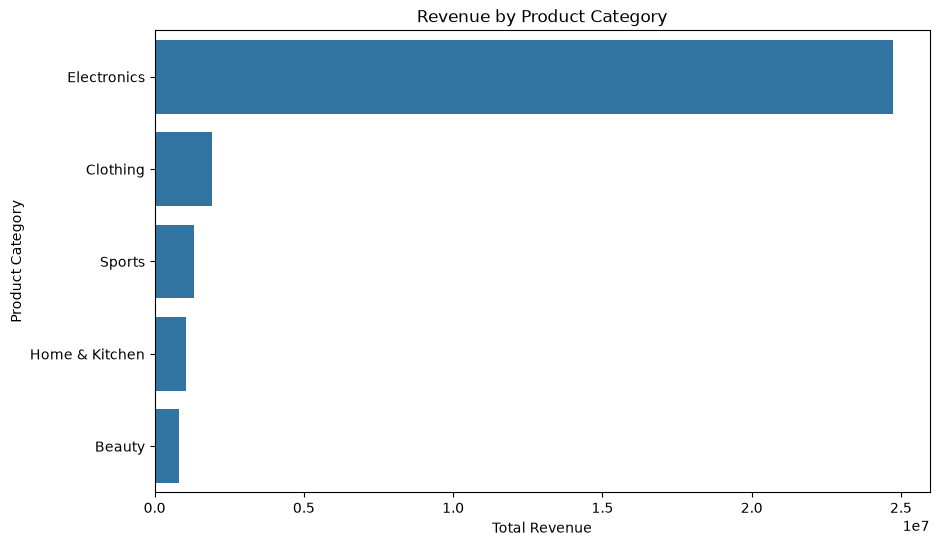

In [24]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

print(category_revenue)

plt.figure(figsize=(10, 6))

sns.barplot(x=category_revenue.values, y=category_revenue.index)

plt.title('Revenue by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')

plt.show()

## 9. Correlation Analysis

The correlation heatmap shows the relationships between numerical variables in the dataset.

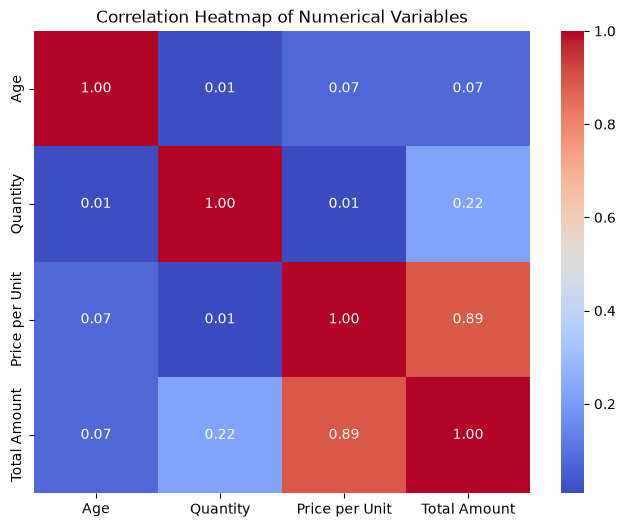

In [25]:
correlation = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

## 10. Additional Visualizations

Additional visualisations are created to gain deeper insights into customer purchasing behaviour and sales patterns.

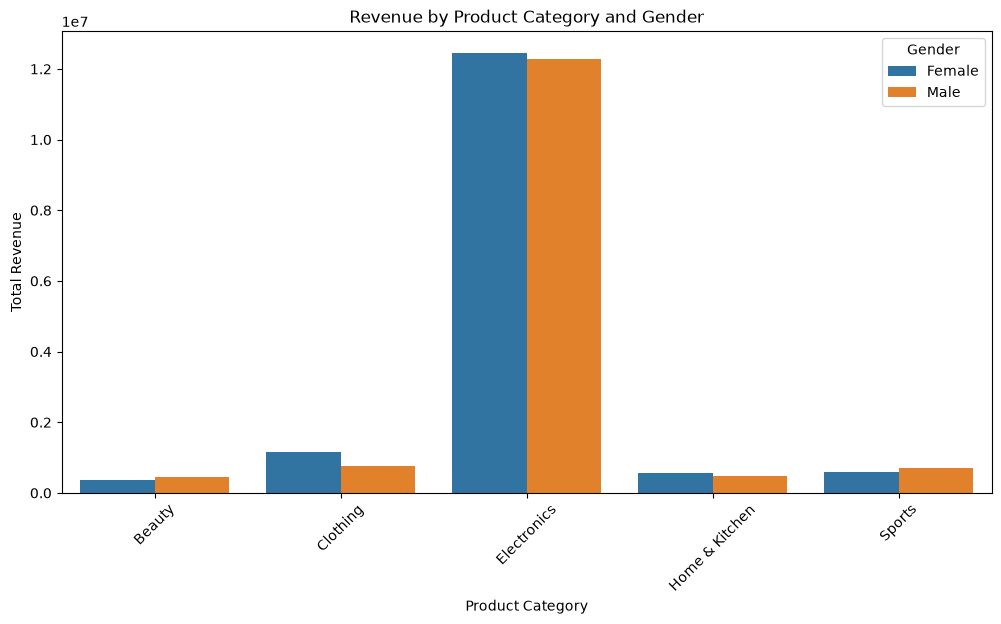

In [26]:
gender_category_sales = df.groupby(
    ['Product Category', 'Gender']
)['Total Amount'].sum().reset_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=gender_category_sales,
    x='Product Category',
    y='Total Amount',
    hue='Gender'
)

plt.title('Revenue by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')

plt.xticks(rotation=45)

plt.show()

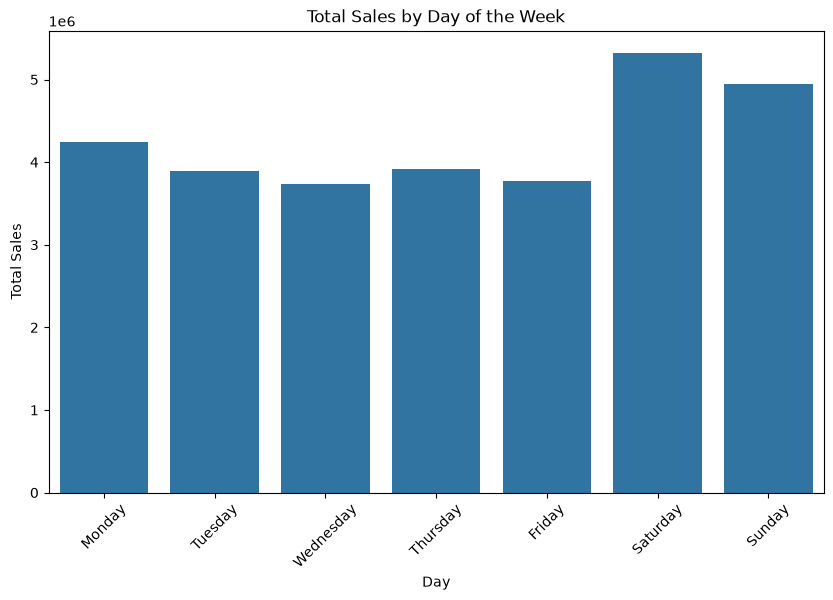

In [27]:
df['Day'] = df['Date'].dt.day_name()

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

daily_sales = df.groupby('Day')['Total Amount'].sum().reindex(day_order)

plt.figure(figsize=(10, 6))

sns.barplot(x=daily_sales.index, y=daily_sales.values)

plt.title('Total Sales by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

## 11. Key Findings

In [28]:
print("Total Revenue:", df['Total Amount'].sum())

print("\nAverage Transaction Value:")
print(df['Total Amount'].mean())

print("\nHighest Revenue Category:")
print(category_revenue.idxmax())

print("\nTop Selling Product:")
print(top_products.idxmax())

print("\nTotal Quantity Sold:")
print(df['Quantity'].sum())

Total Revenue: 29830950.7

Average Transaction Value:
24859.125583333334

Highest Revenue Category:
Electronics

Top Selling Product:
Headphones

Total Quantity Sold:
3620


## 12. Business Recommendations

1. Maintain sufficient inventory for high-selling products such as Headphones.
2. Focus marketing and promotional activities on the Electronics category.
3. Use monthly and quarterly sales trends for inventory planning.
4. Use customer demographics to create targeted marketing campaigns.
5. Regularly analyse sales data to make better business decisions.



## 13. Conclusion

This Exploratory Data Analysis identified important patterns in retail sales, customer demographics, and product performance. The results can help the business improve inventory management, marketing strategies, and overall decision-making.